In [36]:
!pip install gym

     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ------------------------------------- 721.7/721.7 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827705 sha256=cb2e4f4d2c52e72e9ee546289ca980ce988feef2af0b44ea55cc20e7ef29bd8c
  Stored in directory: c:\users\karan\appdata\local\pip\cache\wheels\1d\34\c6\856a1e1eff47d8f18545c833b6138ae1e9f53c7de9bcc5f31d
Successfully built gym



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
class DroneDeliveryEnv:
    def __init__(self):
        self.grid_size = 6
        self.warehouse = (1, 3)  # Starting point
        self.customer = (5, 5)  # Delivery point
        self.no_fly_zones = [(2, 2), (3, 3), (4, 4)]  # Static no-fly zones
        self.state = self.reset()  # Initialize state

        # Action space: Up, Down, Left, Right, Pickup, Drop-off
        self.actions = ['Up', 'Down', 'Left', 'Right', 'Pickup', 'Drop-off']

    def reset(self):
        # Starting position (0, 0) without the package
        self.drone_position = (0, 0)
        self.has_package = False
        self.steps = 0
        return (self.drone_position, self.has_package)

    def step(self, action):
        # Initialize reward and new_position
        reward = -1
        new_position = self.drone_position  # Default to no movement

        # Movement actions
        if action == 'Up':
            new_position = (self.drone_position[0] - 1, self.drone_position[1])
        elif action == 'Down':
            new_position = (self.drone_position[0] + 1, self.drone_position[1])
        elif action == 'Left':
            new_position = (self.drone_position[0], self.drone_position[1] - 1)
        elif action == 'Right':
            new_position = (self.drone_position[0], self.drone_position[1] + 1)

        # Pickup action
        if action == 'Pickup' and self.drone_position == self.warehouse and not self.has_package:
            self.has_package = True
            reward = 25
            return (self.drone_position, self.has_package), reward, False, {}

        # Drop-off action
        elif action == 'Drop-off' and self.drone_position == self.customer and self.has_package:
            self.has_package = False
            reward = 100
            return (self.drone_position, self.has_package), reward, True, {}

        # Check for boundary conditions and no-fly zones (for movement actions)
        if 0 <= new_position[0] < self.grid_size and 0 <= new_position[1] < self.grid_size:
            if new_position not in self.no_fly_zones:
                self.drone_position = new_position
                return (self.drone_position, self.has_package), reward, False, {}

        # If invalid move (out of bounds or into no-fly zone)
        reward = -100
        return (self.drone_position, self.has_package), reward, False, {}

    def render(self):
        grid = np.full((self.grid_size, self.grid_size), '.', dtype=str)
        for zone in self.no_fly_zones:
            grid[zone] = 'X'  # No-fly zones
        if self.has_package:
            grid[self.drone_position] = 'D'
        else:
            grid[self.drone_position] = 'd'
        print(grid)




In [7]:
# Test the deterministic environment with a random agent for 10 steps
env = DroneDeliveryEnv()
for _ in range(100):
    action = random.choice(env.actions)
    state, reward, done, info = env.step(action)
    env.render()
    print(f"State: {state}, Action: {action}, Reward: {reward}")

[['d' '.' '.' '.' '.' '.']
 ['.' '.' '.' '.' '.' '.']
 ['.' '.' 'X' '.' '.' '.']
 ['.' '.' '.' 'X' '.' '.']
 ['.' '.' '.' '.' 'X' '.']
 ['.' '.' '.' '.' '.' '.']]
State: ((0, 0), False), Action: Up, Reward: -100
[['d' '.' '.' '.' '.' '.']
 ['.' '.' '.' '.' '.' '.']
 ['.' '.' 'X' '.' '.' '.']
 ['.' '.' '.' 'X' '.' '.']
 ['.' '.' '.' '.' 'X' '.']
 ['.' '.' '.' '.' '.' '.']]
State: ((0, 0), False), Action: Drop-off, Reward: -1
[['d' '.' '.' '.' '.' '.']
 ['.' '.' '.' '.' '.' '.']
 ['.' '.' 'X' '.' '.' '.']
 ['.' '.' '.' 'X' '.' '.']
 ['.' '.' '.' '.' 'X' '.']
 ['.' '.' '.' '.' '.' '.']]
State: ((0, 0), False), Action: Drop-off, Reward: -1
[['d' '.' '.' '.' '.' '.']
 ['.' '.' '.' '.' '.' '.']
 ['.' '.' 'X' '.' '.' '.']
 ['.' '.' '.' 'X' '.' '.']
 ['.' '.' '.' '.' 'X' '.']
 ['.' '.' '.' '.' '.' '.']]
State: ((0, 0), False), Action: Up, Reward: -100
[['.' '.' '.' '.' '.' '.']
 ['d' '.' '.' '.' '.' '.']
 ['.' '.' 'X' '.' '.' '.']
 ['.' '.' '.' 'X' '.' '.']
 ['.' '.' '.' '.' 'X' '.']
 ['.' '.'

In [9]:
!pip install gymnasium

   ---------------------------------------- 0.0/958.1 kB ? eta -:--:--
   --------------------------------------- 958.1/958.1 kB 13.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


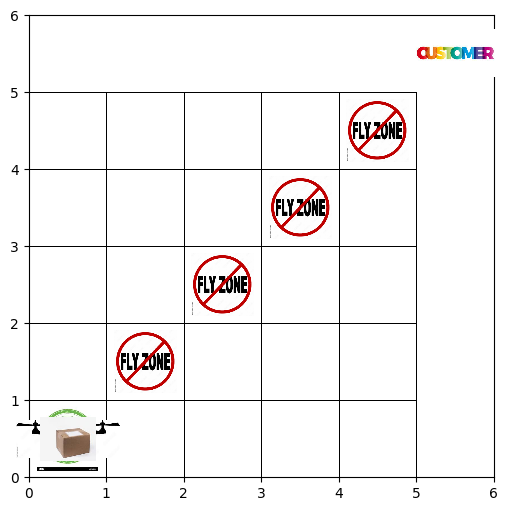

Step 1: Action = 3, Reward = -1, Terminated = False
Step 2: Action = 5, Reward = -1, Terminated = False
Step 3: Action = 2, Reward = -1, Terminated = False
Step 4: Action = 3, Reward = -1, Terminated = False
Step 5: Action = 5, Reward = -1, Terminated = False
Step 6: Action = 2, Reward = -1, Terminated = False
Step 7: Action = 2, Reward = -1, Terminated = False
Step 8: Action = 3, Reward = -1, Terminated = False
Step 9: Action = 1, Reward = -1, Terminated = False
Step 10: Action = 4, Reward = -1, Terminated = False


In [34]:

import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np


class AutonomousDroneDeliveryEnv(gym.Env):
    """This class implements the Autonomous Drone Delivery environment with image rendering."""

    def __init__(self, environment_type='deterministic', multiple_deliveries=False):
        """Initializes the environment.

        Args:
            environment_type (str): Type of environment. Can be 'deterministic' or 'stochastic'.
            multiple_deliveries (bool): Whether the drone must make multiple deliveries in one episode.
        """
        super(AutonomousDroneDeliveryEnv, self).__init__()

        self.environment_type = environment_type
        self.multiple_deliveries = multiple_deliveries

        # Grid size
        self.grid_size = 6
        self.observation_space = spaces.Tuple(
            (spaces.Discrete(self.grid_size), spaces.Discrete(self.grid_size), spaces.Discrete(2))
        )  # (x, y, carrying_package)
        self.action_space = spaces.Discrete(6)  # Up, Down, Left, Right, Pickup, Drop-off

        # Initial positions
        self.warehouse_pos = np.array([0, 0])  # Starting point
        self.customer_pos = np.array([5, 5])  # Delivery point
        self.no_fly_zones = np.array([[1, 1], [2, 2], [3, 3], [4, 4]])  # Static obstacles
        self.package_pos = self.warehouse_pos  # Package starts at the warehouse

        # Drone state
        self.drone_pos = np.array([0, 0])
        self.carrying_package = False
        self.delivered = False

        # Rendering
        self.fig, self.ax = plt.subplots(figsize=(6, 6))

    def reset(self):
        """Resets the environment to the initial state."""
        self.drone_pos = self.warehouse_pos
        self.carrying_package = False
        self.delivered = False
        self.package_pos = self.warehouse_pos
        return self._get_observation()

    def step(self, action):
        """Executes one timestep in the environment.

        Args:
            action (int): The action to take (0: Up, 1: Down, 2: Left, 3: Right, 4: Pickup, 5: Drop-off).

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        reward = -1  # Default reward for each step
        terminated = False
        truncated = False
        info = {}

        # Handle movement actions
        if action == 0:  # Up
            new_pos = self.drone_pos + np.array([0, 1])
        elif action == 1:  # Down
            new_pos = self.drone_pos + np.array([0, -1])
        elif action == 2:  # Left
            new_pos = self.drone_pos + np.array([-1, 0])
        elif action == 3:  # Right
            new_pos = self.drone_pos + np.array([1, 0])
        else:
            new_pos = self.drone_pos  # No movement for Pickup/Drop-off

        # Check if the new position is valid
        if self._is_valid_position(new_pos):
            self.drone_pos = new_pos

        # Handle Pickup action
        if action == 4:  # Pickup
            if np.array_equal(self.drone_pos, self.package_pos) and not self.carrying_package:
                self.carrying_package = True
                reward += 25  # Reward for picking up the package

        # Handle Drop-off action
        if action == 5:  # Drop-off
            if np.array_equal(self.drone_pos, self.customer_pos) and self.carrying_package:
                self.carrying_package = False
                self.delivered = True
                reward += 100  # Reward for successful delivery
                if not self.multiple_deliveries:
                    terminated = True  # Episode ends after single delivery

        # Check if the drone enters a no-fly zone
        if self._is_in_no_fly_zone(self.drone_pos):
            reward -= 100
            terminated = True  # Episode ends if drone enters a no-fly zone

        # Return observation, reward, and termination status
        return self._get_observation(), reward, terminated, truncated, info

    def _is_valid_position(self, pos):
        """Checks if a position is within the grid and not in a no-fly zone."""
        return (0 <= pos[0] < self.grid_size and 0 <= pos[1] < self.grid_size and
                not self._is_in_no_fly_zone(pos))

    def _is_in_no_fly_zone(self, pos):
        """Checks if a position is in a no-fly zone."""
        return any(np.array_equal(pos, zone) for zone in self.no_fly_zones)

    def _get_observation(self):
        """Returns the current observation."""
        return tuple(self.drone_pos) + (int(self.carrying_package),)

    def render(self, mode='human', plot=False):
        """Renders the environment with images for different characters."""
        # self.ax.clear()
        self.ax.set_xlim(0, self.grid_size)
        self.ax.set_ylim(0, self.grid_size)

        # Plot grid
        for x in range(self.grid_size):
            for y in range(self.grid_size):
                self.ax.plot([x, x], [0, self.grid_size - 1], color='black', linewidth=0.5)
                self.ax.plot([0, self.grid_size - 1], [y, y], color='black', linewidth=0.5)

        # Helper function to plot images
        def plot_image(image_path, position, zoom=0.2):
            """Plots an image at the given position."""
            img = plt.imread(image_path)
            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(imagebox, (position[0] + 0.5, position[1] + 0.5), frameon=False)
            self.ax.add_artist(ab)

        # Plot no-fly zones
        for zone in self.no_fly_zones:
            plot_image('./images/noflyzone.png', zone)

        # Plot warehouse
        plot_image('./images/warehouse.jpg', self.warehouse_pos)

        # Plot customer location
        plot_image('./images/customer.jpg', self.customer_pos)

        # Plot drone
        if self.carrying_package:
            plot_image('./images/drone with image.jpg', self.drone_pos)
        else:
            plot_image('./images/drone.jpg', self.drone_pos)

        # Plot package
        if not self.carrying_package:
            plot_image('./images/box.jpg', self.package_pos)

        if plot:
            plt.show()
        else:
            plt.draw()
            plt.pause(0.01)


# Example usage
env = AutonomousDroneDeliveryEnv(environment_type='deterministic', multiple_deliveries=False)
obs = env.reset()
env.render(plot=True)


# for t in range(10):
#     action = env.action_space.sample()  # Random action
#     next_state, reward, done, truncated, info = env.step(action)
#     print(f"Timestep: {t+1}, Action: {action}, Reward: {reward}, State: {state}, Carrying Object: {env.carrying_object}")
#     env.render()
#     state = next_state
#     if done:
#         print("Episode finished.")
#         break

# Example actions
# actions = [3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 4, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 5]
for t in range(10):  # Replace 10 with the desired number of steps
    action = env.action_space.sample()  # Sample a random action
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {terminated}")
    env.render(plot=True)
   
    if terminated:
        print("Episode terminated early!")
        break

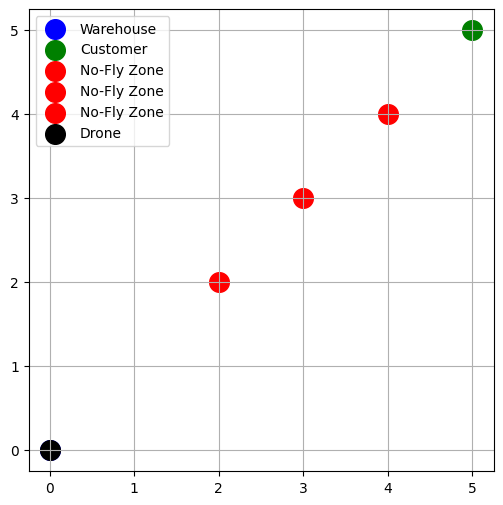

Step 1: Action = 1, Reward = -1, Terminated = False


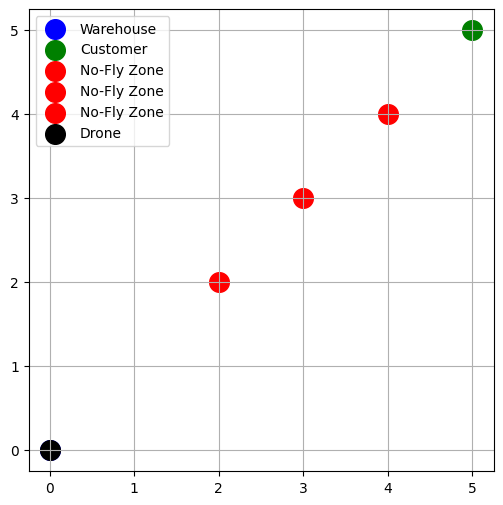

Step 2: Action = 0, Reward = -1, Terminated = False


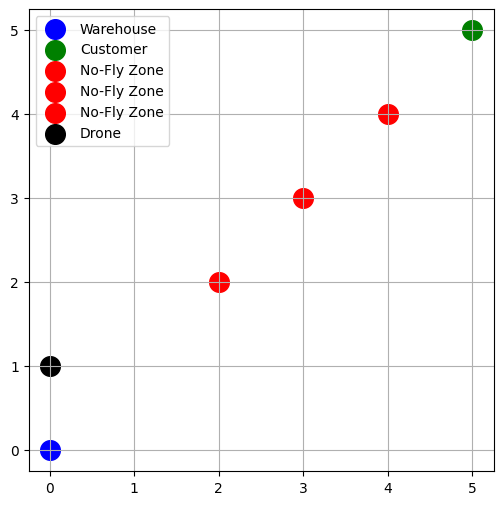

Step 3: Action = 2, Reward = -1, Terminated = False


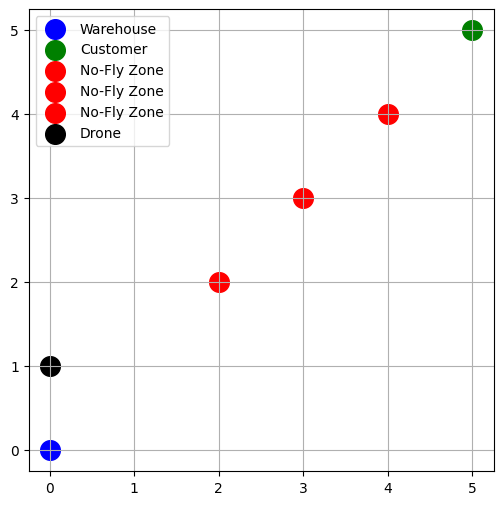

Step 4: Action = 5, Reward = -1, Terminated = False


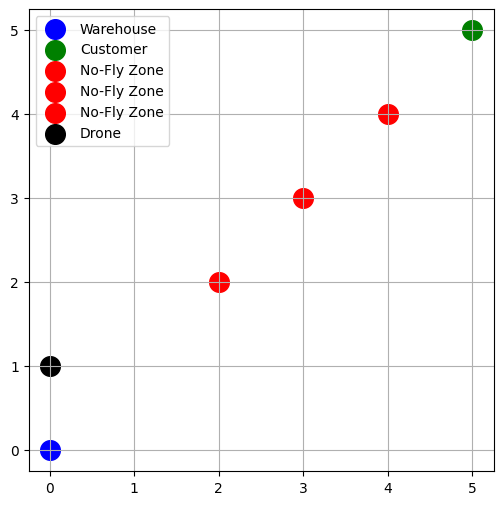

Step 5: Action = 0, Reward = -1, Terminated = False


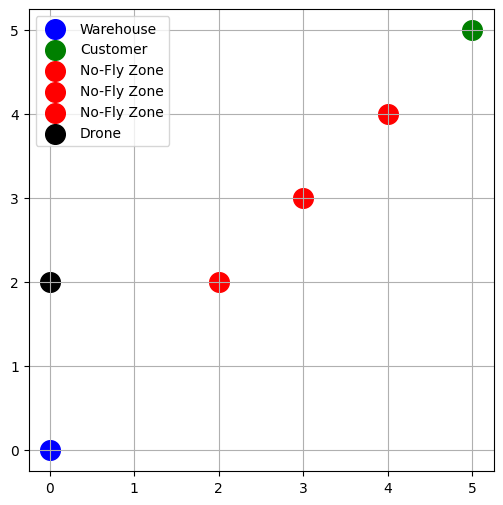

Step 6: Action = 1, Reward = -1, Terminated = False


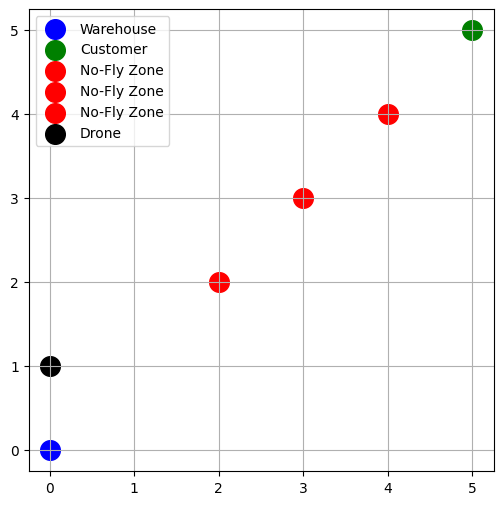

Step 7: Action = 3, Reward = -1, Terminated = False


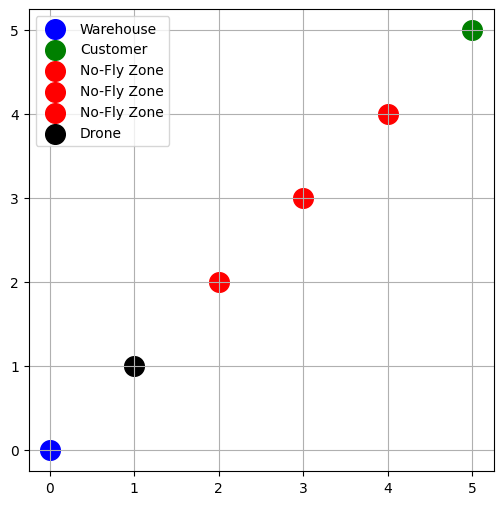

Step 8: Action = 1, Reward = -1, Terminated = False


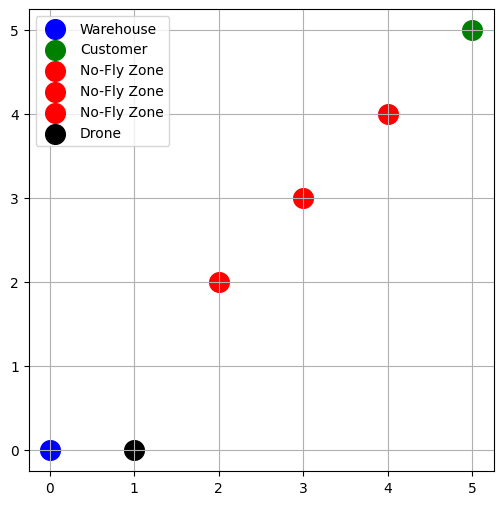

Step 9: Action = 2, Reward = -1, Terminated = False


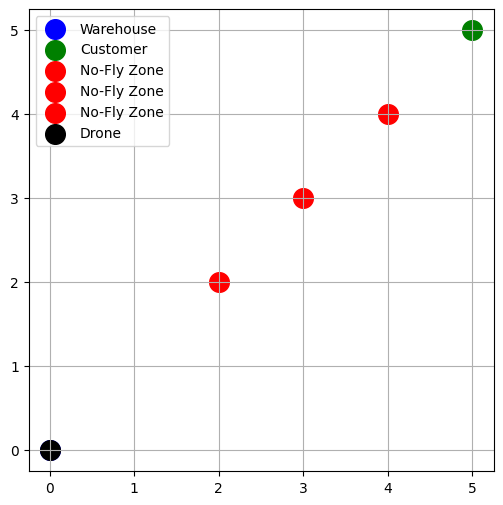

Step 10: Action = 1, Reward = -1, Terminated = False


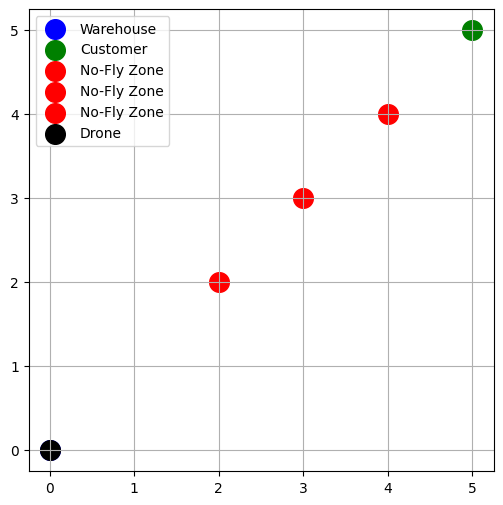

In [40]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)  # Up, Down, Left, Right, Pickup, Drop-off
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])  # Drone (x, y) and package status
        
        self.warehouse_pos = np.array([0, 0])
        self.customer_pos = np.array([5, 5])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([4, 4])]
        
        self.reset()
    
    def reset(self):
        self.drone_pos = self.warehouse_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1  # Default step penalty
        terminated = False

        if action == 0 and self.drone_pos[1] < self.grid_size - 1:  # Up
            self.drone_pos[1] += 1
        elif action == 1 and self.drone_pos[1] > 0:  # Down
            self.drone_pos[1] -= 1
        elif action == 2 and self.drone_pos[0] > 0:  # Left
            self.drone_pos[0] -= 1
        elif action == 3 and self.drone_pos[0] < self.grid_size - 1:  # Right
            self.drone_pos[0] += 1
        elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):  # Pickup
            self.package_picked = True
            reward = 25
        elif action == 5 and np.array_equal(self.drone_pos, self.customer_pos) and self.package_picked:  # Drop-off
            reward = 100
            terminated = True
        
        if any(np.array_equal(self.drone_pos, zone) for zone in self.no_fly_zones):
            reward = -100
            terminated = True
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        ax.scatter(*self.warehouse_pos, color='blue', s=200, label='Warehouse')
        ax.scatter(*self.customer_pos, color='green', s=200, label='Customer')
        for zone in self.no_fly_zones:
            ax.scatter(*zone, color='red', s=200, label='No-Fly Zone')
        
        ax.scatter(*self.drone_pos, color='black', s=200, label='Drone')
        plt.legend()
        plt.show()

# Running a random agent for 10 timesteps
env = DroneDeliveryEnvironment()
obs = env.reset()

env.render()
for t in range(10):
    action = env.action_space.sample()
    obs, reward, done, _ = env.step(action)
    print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
    env.render()
    if done:
        break

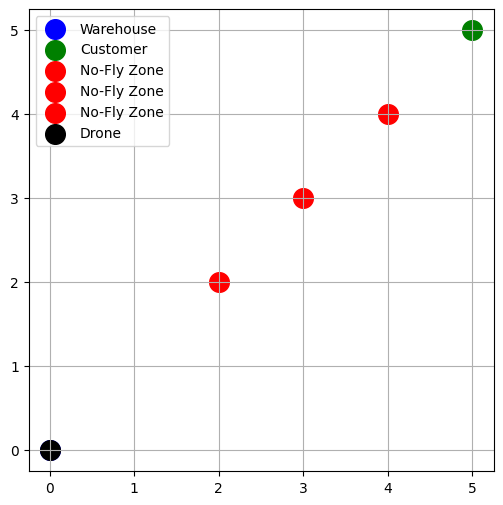

Step 1: Action = 3, Reward = -1, Terminated = False


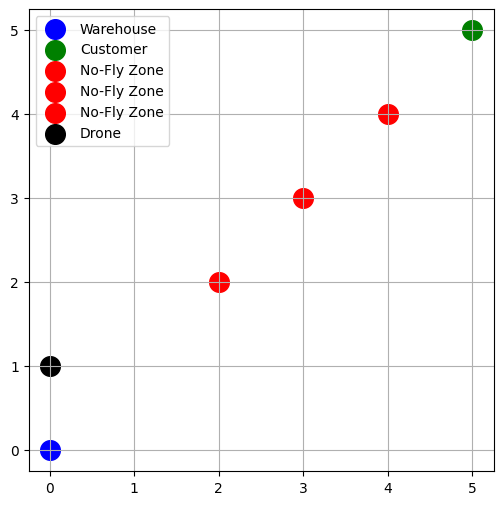

Step 2: Action = 4, Reward = -1, Terminated = False


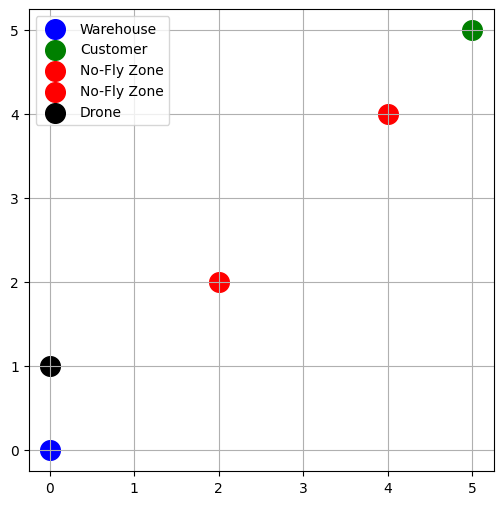

Step 3: Action = 3, Reward = -1, Terminated = False


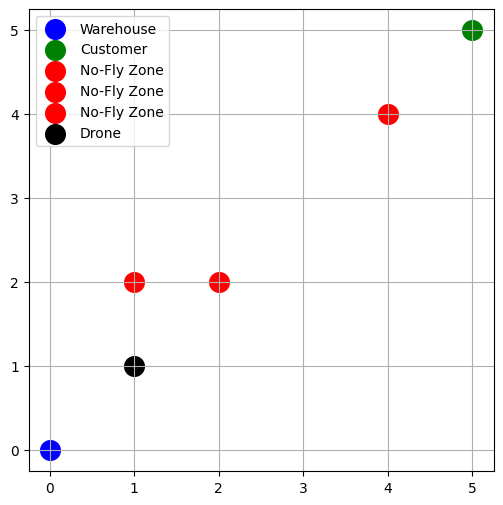

Step 4: Action = 3, Reward = -1, Terminated = False


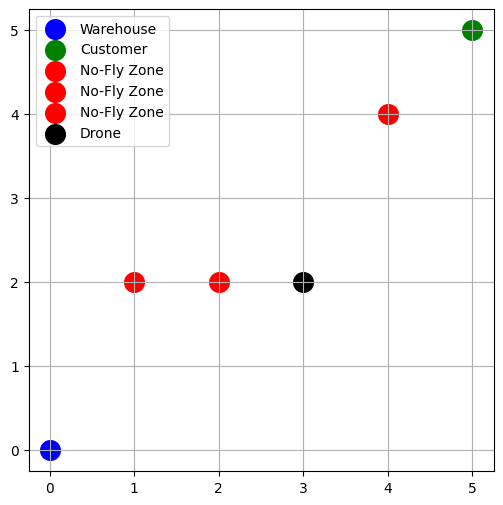

Step 5: Action = 4, Reward = -1, Terminated = False


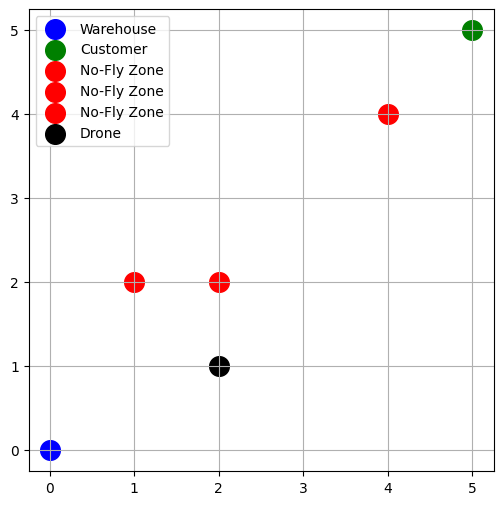

Step 6: Action = 5, Reward = -1, Terminated = False


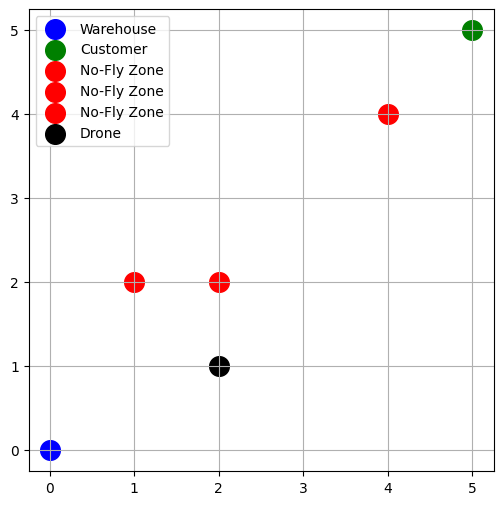

Step 7: Action = 0, Reward = -100, Terminated = True


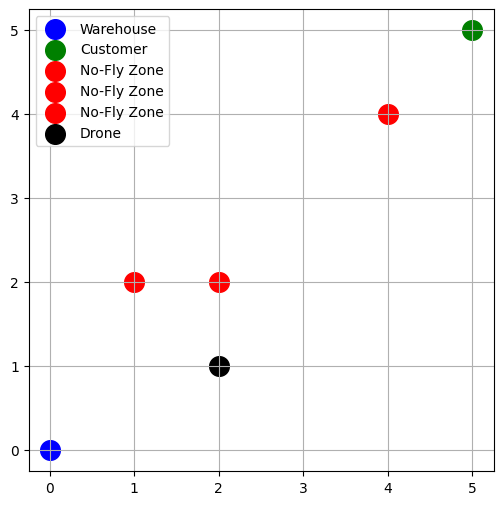

In [44]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self, stochastic=False):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)  # Up, Down, Left, Right, Pickup, Drop-off
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])  # Drone (x, y) and package status
        
        self.warehouse_pos = np.array([0, 0])
        self.customer_pos = np.array([5, 5])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([4, 4])]
        
        self.stochastic = stochastic
        self.reset()
    
    def reset(self, start_pos=None, target_pos=None):
        self.drone_pos = start_pos if start_pos is not None else self.warehouse_pos.copy()
        self.target_pos = target_pos if target_pos is not None else self.customer_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1  # Default step penalty
        terminated = False
        new_pos = self.drone_pos.copy()
        
        if action == 0:  # Up
            new_pos[1] += 1 if self.drone_pos[1] < self.grid_size - 1 else 0
        elif action == 1:  # Down
            new_pos[1] -= 1 if self.drone_pos[1] > 0 else 0
        elif action == 2:  # Left
            new_pos[0] -= 1 if self.drone_pos[0] > 0 else 0
        elif action == 3:  # Right
            new_pos[0] += 1 if self.drone_pos[0] < self.grid_size - 1 else 0
        elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):  # Pickup
            self.package_picked = True
            reward = 25
        elif action == 5 and np.array_equal(self.drone_pos, self.target_pos) and self.package_picked:  # Drop-off
            reward = 100
            terminated = True
        
        if self.stochastic:
            if np.random.rand() < 0.1:  # 10% chance of deviation
                new_pos += np.random.choice([-1, 1], size=2)
                new_pos = np.clip(new_pos, 0, self.grid_size - 1)
            if np.random.rand() < 0.5:  # 10% chance of new no-fly zone appearing or disappearing
                if np.random.rand() < 0.5 and len(self.no_fly_zones) > 0:  # Remove a random no-fly zone
                    self.no_fly_zones.pop(np.random.randint(len(self.no_fly_zones)))
                else:  # Add a new random no-fly zone
                    new_zone = np.random.randint(0, self.grid_size, size=2)
                    if not np.array_equal(new_zone, self.warehouse_pos) and not np.array_equal(new_zone, self.target_pos):
                        self.no_fly_zones.append(new_zone)
                        self.no_fly_zones = [np.array(zone) for zone in set(tuple(zone) for zone in self.no_fly_zones)]
        
        if not any(np.array_equal(new_pos, zone) for zone in self.no_fly_zones):
            self.drone_pos = new_pos
        else:
            reward = -100
            terminated = True
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        ax.scatter(*self.warehouse_pos, color='blue', s=200, label='Warehouse')
        ax.scatter(*self.target_pos, color='green', s=200, label='Customer')
        for zone in self.no_fly_zones:
            ax.scatter(*zone, color='red', s=200, label='No-Fly Zone')
        
        ax.scatter(*self.drone_pos, color='black', s=200, label='Drone')
        plt.legend()
        plt.show()

# Running a random agent for 10 timesteps in stochastic mode
env = DroneDeliveryEnvironment(stochastic=True)
obs = env.reset()

env.render()
for t in range(10):
    action = env.action_space.sample()
    obs, reward, done, _ = env.step(action)
    print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
    env.render()
    if done:
        break

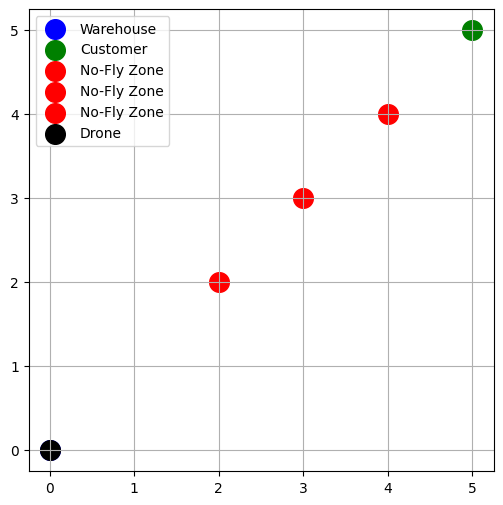

Step 1: Action = 2, Reward = -1, Terminated = False


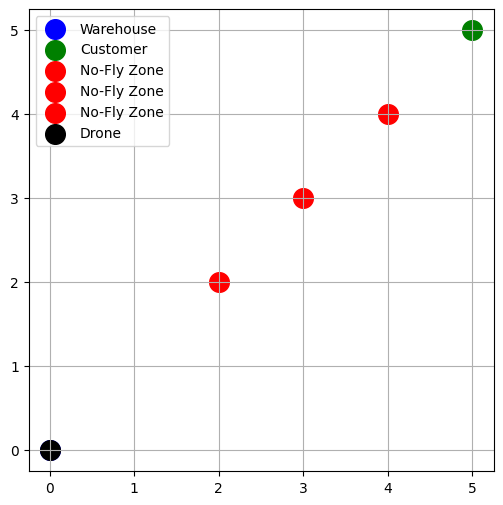

Step 2: Action = 2, Reward = -1, Terminated = False


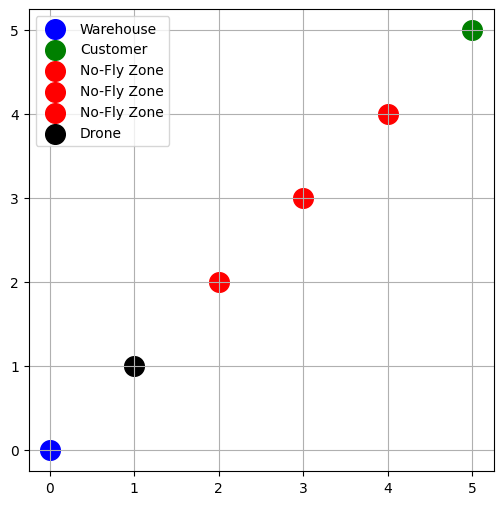

Step 3: Action = 5, Reward = -1, Terminated = False


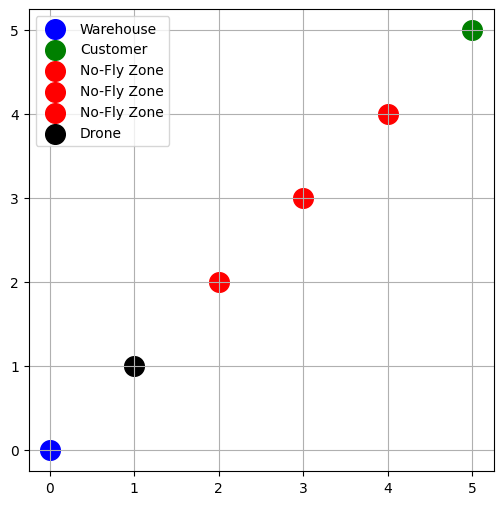

Step 4: Action = 1, Reward = -1, Terminated = False


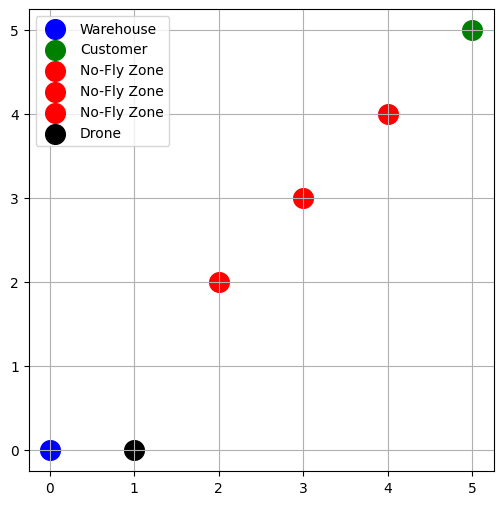

Step 5: Action = 1, Reward = -1, Terminated = False


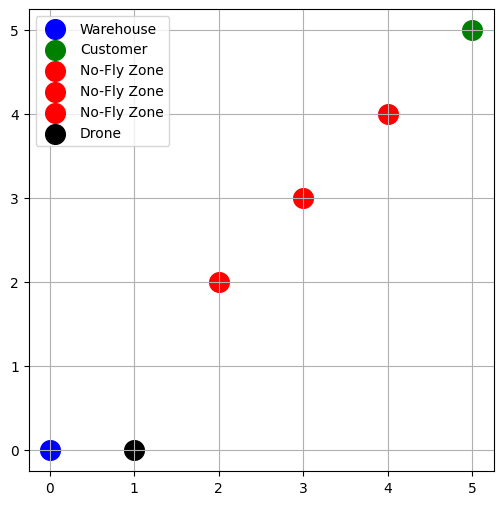

Step 6: Action = 3, Reward = -1, Terminated = False


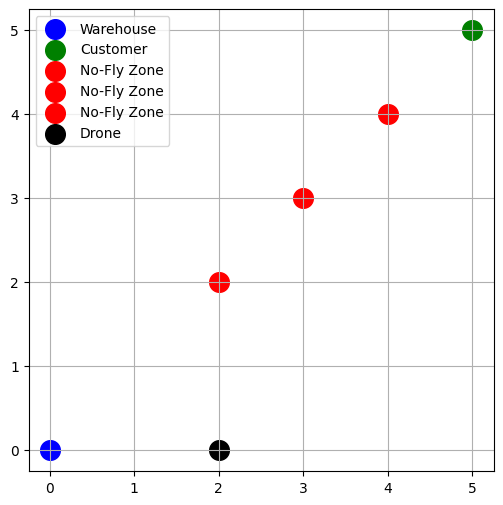

Step 7: Action = 3, Reward = -1, Terminated = False


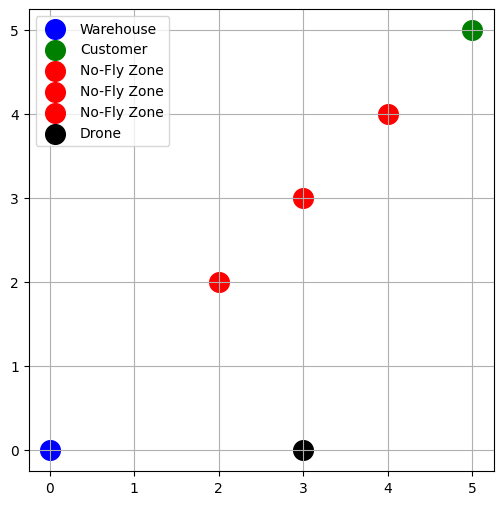

Step 8: Action = 2, Reward = -1, Terminated = False


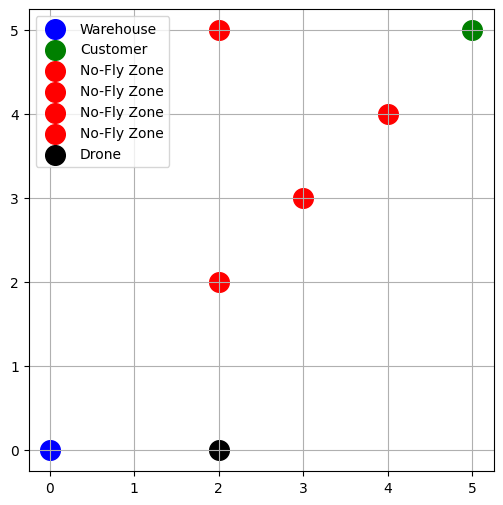

Step 9: Action = 1, Reward = -1, Terminated = False


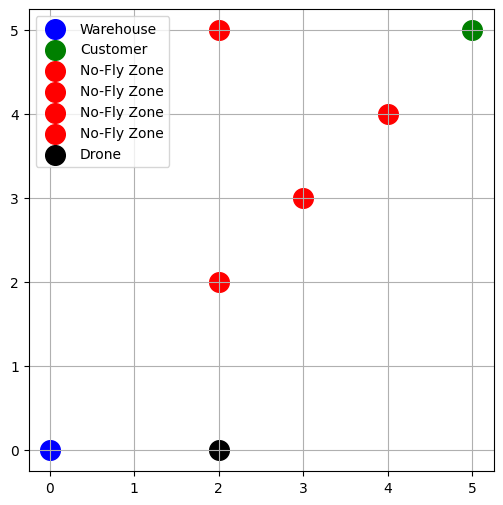

Step 10: Action = 4, Reward = -1, Terminated = False


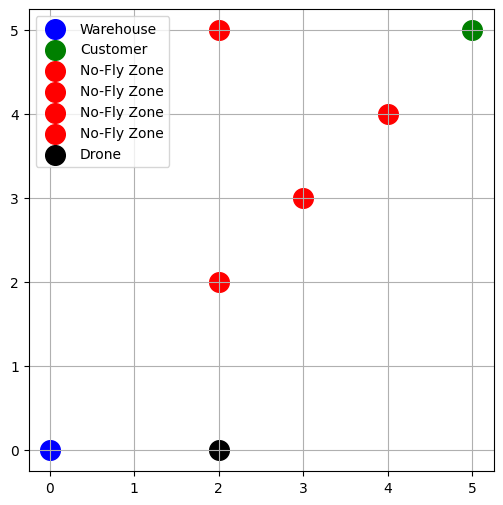

In [45]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self, stochastic=False):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])
        
        self.warehouse_pos = np.array([0, 0])
        self.customer_pos = np.array([5, 5])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([4, 4])]
        
        self.stochastic = stochastic
        self.reset()
    
    def reset(self, start_pos=None, target_pos=None):
        self.drone_pos = start_pos if start_pos is not None else self.warehouse_pos.copy()
        self.target_pos = target_pos if target_pos is not None else self.customer_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1
        terminated = False
        new_pos = self.drone_pos.copy()
        
        if action == 0:
            new_pos[1] += 1 if self.drone_pos[1] < self.grid_size - 1 else 0
        elif action == 1:
            new_pos[1] -= 1 if self.drone_pos[1] > 0 else 0
        elif action == 2:
            new_pos[0] -= 1 if self.drone_pos[0] > 0 else 0
        elif action == 3:
            new_pos[0] += 1 if self.drone_pos[0] < self.grid_size - 1 else 0
        elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):
            self.package_picked = True
            reward = 25
        elif action == 5 and np.array_equal(self.drone_pos, self.target_pos) and self.package_picked:
            reward = 100
            terminated = True
        
        if self.stochastic:
            if np.random.rand() < 0.1:
                new_pos += np.random.choice([-1, 1], size=2)
                new_pos = np.clip(new_pos, 0, self.grid_size - 1)
            if np.random.rand() < 0.5:
                if np.random.rand() < 0.5 and len(self.no_fly_zones) > 0:
                    self.no_fly_zones.pop(np.random.randint(len(self.no_fly_zones)))
                else:
                    new_zone = np.random.randint(0, self.grid_size, size=2)
                    if not np.array_equal(new_zone, self.warehouse_pos) and not np.array_equal(new_zone, self.target_pos):
                        self.no_fly_zones.append(new_zone)
                        self.no_fly_zones = [np.array(zone) for zone in set(tuple(zone) for zone in self.no_fly_zones)]

            # Probability-based target change
            if np.random.rand() < 0.05:
                self.target_pos = np.random.randint(0, self.grid_size, size=2)
                print(f"New target assigned: {self.target_pos}")
        
        if any(np.array_equal(new_pos, zone) for zone in self.no_fly_zones):
            reward = -100
            self.drone_pos = self.warehouse_pos.copy()
            print("No-fly zone encountered! Returning to start.")
        else:
            self.drone_pos = new_pos
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        ax.scatter(*self.warehouse_pos, color='blue', s=200, label='Warehouse')
        ax.scatter(*self.target_pos, color='green', s=200, label='Customer')
        for zone in self.no_fly_zones:
            ax.scatter(*zone, color='red', s=200, label='No-Fly Zone')
        
        ax.scatter(*self.drone_pos, color='black', s=200, label='Drone')
        plt.legend()
        plt.show()

# Running a random agent for 10 timesteps in stochastic mode
env = DroneDeliveryEnvironment(stochastic=True)
obs = env.reset()

env.render()
for t in range(10):
    action = env.action_space.sample()
    obs, reward, done, _ = env.step(action)
    print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
    env.render()
    if done:
        break

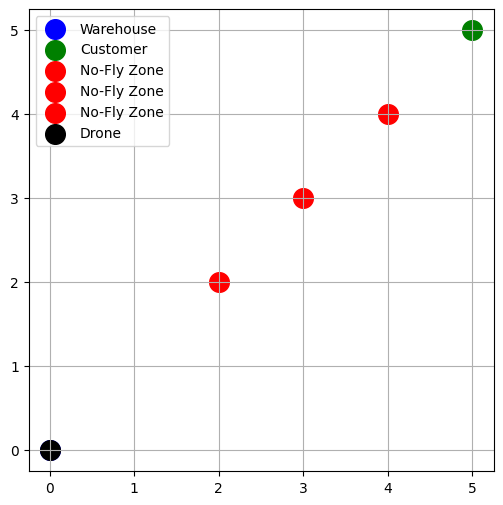

Step 1: Action = 5, Reward = -1, Terminated = False


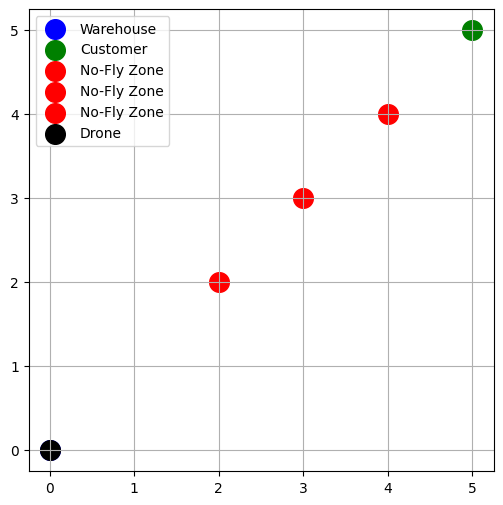

No-fly zone removed at [2 2]
Step 2: Action = 2, Reward = -1, Terminated = False


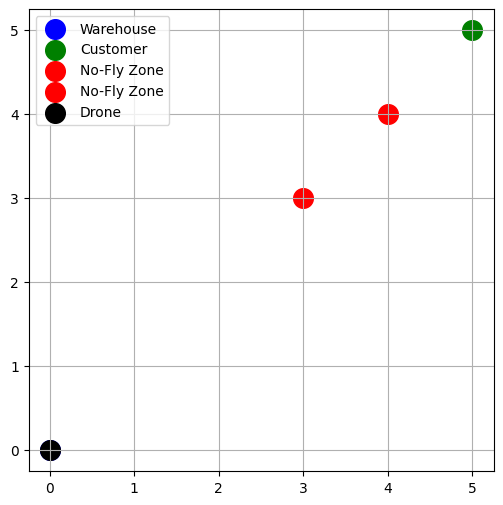

No-fly zone removed at [4 4]
New target assigned: [3 0]
Step 3: Action = 2, Reward = -1, Terminated = False


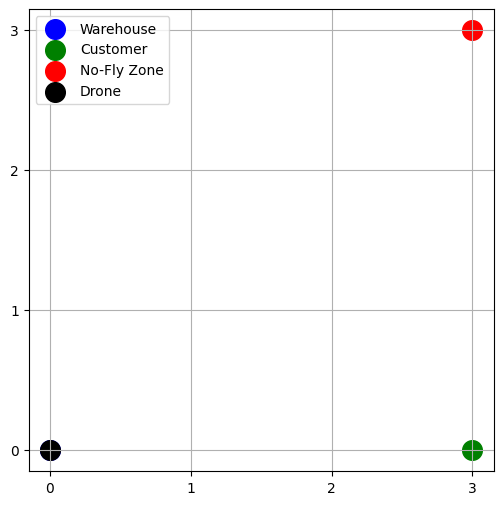

New no-fly zone added at [5 2]
Step 4: Action = 0, Reward = -1, Terminated = False


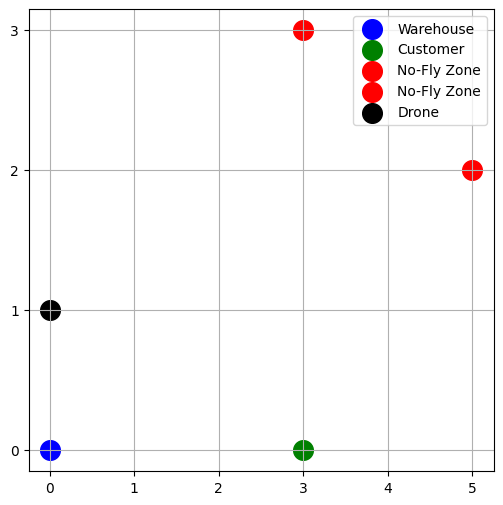

Wind effect! Drone deviates to [1 2]
Step 5: Action = 3, Reward = -1, Terminated = False


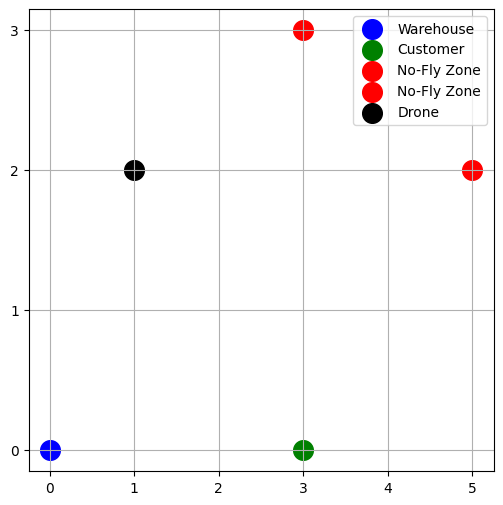

Step 6: Action = 5, Reward = -1, Terminated = False


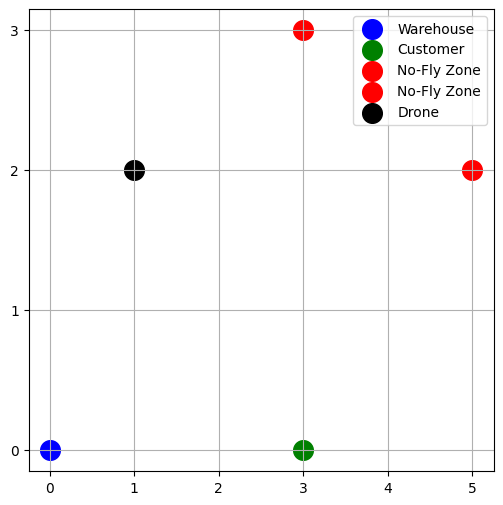

Step 7: Action = 1, Reward = -1, Terminated = False


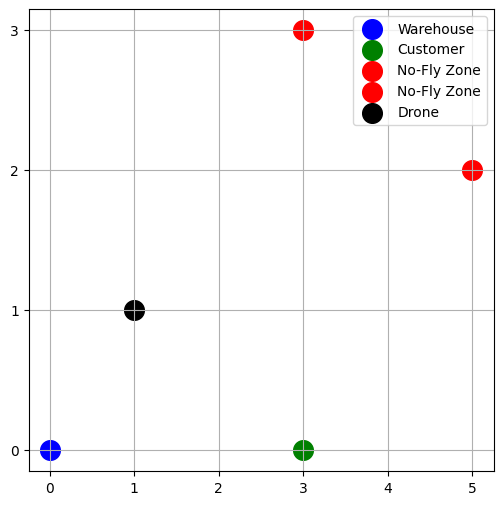

New no-fly zone added at [0 5]
Step 8: Action = 4, Reward = -1, Terminated = False


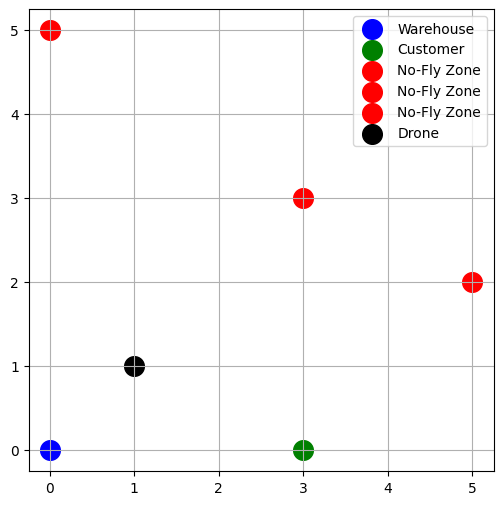

New no-fly zone added at [1 2]
Step 9: Action = 2, Reward = -1, Terminated = False


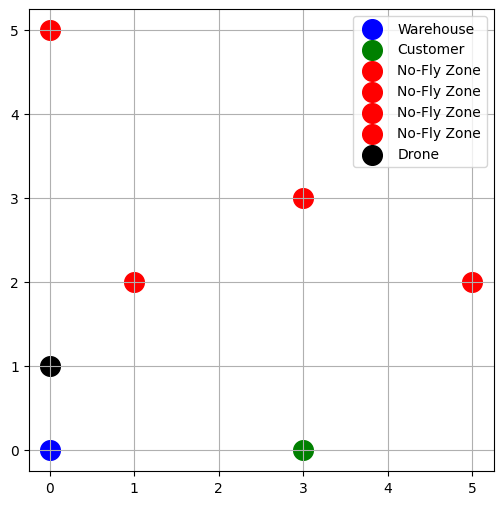

New no-fly zone added at [4 3]
Step 10: Action = 4, Reward = -1, Terminated = False


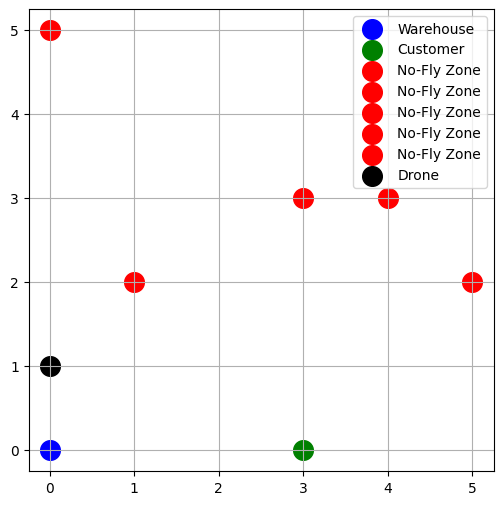

In [46]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self, stochastic=False):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])
        
        self.warehouse_pos = np.array([0, 0])
        self.customer_pos = np.array([5, 5])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([4, 4])]
        
        self.stochastic = stochastic
        self.reset()
    
    def reset(self, start_pos=None, target_pos=None):
        self.drone_pos = start_pos if start_pos is not None else self.warehouse_pos.copy()
        self.target_pos = target_pos if target_pos is not None else self.customer_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1
        terminated = False
        new_pos = self.drone_pos.copy()
        
        if np.random.rand() < 0.1:
            deviation = np.random.choice([-1, 1], size=2)
            print(f"Wind effect! Drone deviates to {new_pos + deviation}")
            new_pos += deviation
        else:
            if action == 0:
                new_pos[1] += 1 if self.drone_pos[1] < self.grid_size - 1 else 0
            elif action == 1:
                new_pos[1] -= 1 if self.drone_pos[1] > 0 else 0
            elif action == 2:
                new_pos[0] -= 1 if self.drone_pos[0] > 0 else 0
            elif action == 3:
                new_pos[0] += 1 if self.drone_pos[0] < self.grid_size - 1 else 0
            elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):
                self.package_picked = True
                reward = 25
            elif action == 5 and np.array_equal(self.drone_pos, self.target_pos) and self.package_picked:
                reward = 100
                terminated = True
        
        if self.stochastic:
            if np.random.rand() < 0.5:
                if np.random.rand() < 0.5 and len(self.no_fly_zones) > 0:
                    removed_zone = self.no_fly_zones.pop(np.random.randint(len(self.no_fly_zones)))
                    print(f"No-fly zone removed at {removed_zone}")
                else:
                    new_zone = np.random.randint(0, self.grid_size, size=2)
                    if not np.array_equal(new_zone, self.warehouse_pos) and not np.array_equal(new_zone, self.target_pos):
                        self.no_fly_zones.append(new_zone)
                        self.no_fly_zones = [np.array(zone) for zone in set(tuple(zone) for zone in self.no_fly_zones)]
                        print(f"New no-fly zone added at {new_zone}")
            
            if np.random.rand() < 0.05:
                self.target_pos = np.random.randint(0, self.grid_size, size=2)
                print(f"New target assigned: {self.target_pos}")
        
        if any(np.array_equal(new_pos, zone) for zone in self.no_fly_zones):
            reward = -100
            self.drone_pos = self.warehouse_pos.copy()
            print("No-fly zone encountered! Returning to start.")
        else:
            self.drone_pos = np.clip(new_pos, 0, self.grid_size - 1)
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        ax.scatter(*self.warehouse_pos, color='blue', s=200, label='Warehouse')
        ax.scatter(*self.target_pos, color='green', s=200, label='Customer')
        for zone in self.no_fly_zones:
            ax.scatter(*zone, color='red', s=200, label='No-Fly Zone')
        
        ax.scatter(*self.drone_pos, color='black', s=200, label='Drone')
        plt.legend()
        plt.show()

# Running a random agent for 10 timesteps in stochastic mode
env = DroneDeliveryEnvironment(stochastic=True)
obs = env.reset()

env.render()
for t in range(10):
    action = env.action_space.sample()
    obs, reward, done, _ = env.step(action)
    print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
    env.render()
    if done:
        break

In [135]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self, stochastic=False):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])
        
        self.warehouse_pos = np.array([3, 1])
        self.customer_pos = np.array([4, 4])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([1, 4])]
        self.start_pos = np.array([0, 0])
        self.stochastic = stochastic
        self.reset()
    
    def reset(self, start_pos=None, target_pos=None):
        self.drone_pos = start_pos if start_pos is not None else self.start_pos.copy()
        self.target_pos = target_pos if target_pos is not None else self.customer_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1
        terminated = False
        new_pos = self.drone_pos.copy()
 
        if action == 0:
            new_pos[1] += 1 if self.drone_pos[1] < self.grid_size - 1 else 0
        elif action == 1:
            new_pos[1] -= 1 if self.drone_pos[1] > 0 else 0
        elif action == 2:
            new_pos[0] -= 1 if self.drone_pos[0] > 0 else 0
        elif action == 3:
            new_pos[0] += 1 if self.drone_pos[0] < self.grid_size - 1 else 0
        elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):
            self.package_picked = True
            reward = 25
        elif action == 5 and np.array_equal(self.drone_pos, self.target_pos) and self.package_picked:
            self.package_picked = False
            reward = 100
            terminated = True
        
        if self.stochastic:
            if np.random.rand() < 0.1:  # with 10% probability, wind effect occurs
                deviation = np.random.choice([-1, 1], size=2)
                print(f"Wind effect! Drone deviates to {new_pos + deviation}")
                new_pos += deviation
                
            if np.random.rand() < 0.5:
                if np.random.rand() < 0.5 and len(self.no_fly_zones) > 0:
                    removed_zone = self.no_fly_zones.pop(np.random.randint(len(self.no_fly_zones)))
                    print(f"No-fly zone removed at {removed_zone}")
                else:
                    new_zone = np.random.randint(0, self.grid_size, size=2)
                    if not np.array_equal(new_zone, self.warehouse_pos) and not np.array_equal(new_zone, self.target_pos):
                        self.no_fly_zones.append(new_zone)
                        self.no_fly_zones = [np.array(zone) for zone in set(tuple(zone) for zone in self.no_fly_zones)]
                        print(f"New no-fly zone added at {new_zone}")
            
            if np.random.rand() < 0.05:
                self.target_pos = np.random.randint(0, self.grid_size, size=2)
                print(f"New target assigned: {self.target_pos}")
        
        if any(np.array_equal(new_pos, zone) for zone in self.no_fly_zones):
            reward = -100
            self.drone_pos = self.warehouse_pos.copy()
            print("No-fly zone encountered! Returning to start.")
        else:
            self.drone_pos = np.clip(new_pos, 0, self.grid_size - 1)
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        def add_image(ax, img_path, pos, zoom=0.5):
            img = plt.imread(img_path)
            imagebox = OffsetImage(img, zoom=0.2)
            ab = AnnotationBbox(imagebox, np.add(pos, [0.5, 0.5]), frameon=False)
            ax.add_artist(ab)
        print(self.package_picked)
        if not self.package_picked:
            add_image(ax, './images/box.jpg', self.warehouse_pos)  # Show warehouse if package is present
        
        add_image(ax, './images/customer.jpg', self.customer_pos)
        for zone in self.no_fly_zones:
            add_image(ax, './images/noflyzone.png', zone)
        
        drone_img = './images/drone with image.jpg' if self.package_picked else './images/drone.jpg'
        add_image(ax, drone_img, self.drone_pos)
        
        plt.show()

# Running a random agent for 10 timesteps in stochastic mode
# env = DroneDeliveryEnvironment(stochastic=False)
# obs = env.reset()

# env.render()
# for t in range(10):
#     action = env.action_space.sample()
#     obs, reward, done, _ = env.step(action)
#     print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
#     env.render()
#     if done:
#         break

In [136]:
env = DroneDeliveryEnvironment(stochastic=False)

Step 10: Action = 0, Reward = -1, Terminated = False
True


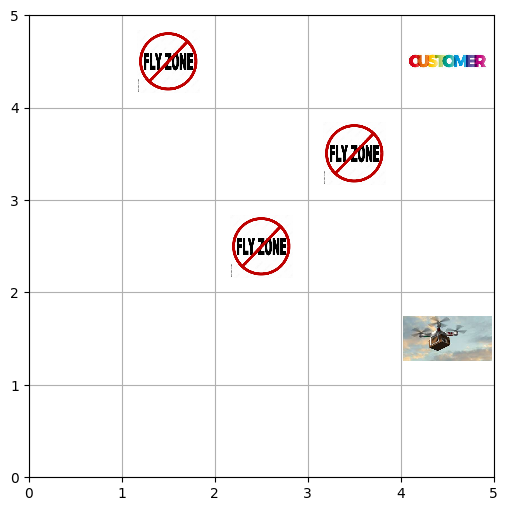

In [143]:

obs, reward, done, _ = env.step(5)
print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
env.render()